In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone

mist = MIST_Isochrone()

# Grids
age_grid  = np.linspace(6.0, 10.2, 60)   # log(age/yr)
feh_grid  = np.linspace(-2.5, 0.5, 31)
mass_grid = np.linspace(0.1, 10.0, 200)

PyMultiNest not imported.  MultiNest fits will not work.


In [2]:
# Bands
bands = ['J_mag', 'H_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag', 'W1_mag', 'W2_mag']
compare_bands = ['J_mag', 'K_mag', 'G_mag', 'BP_mag', 'RP_mag']

# Initialize cubes
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {band: np.full(shape, np.nan) for band in bands}

# Build interpolators
print("Building MIST interpolators (this may take a few minutes)...")
for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty:
            continue
        iso = iso.sort_values('initial_mass')
        for band in bands:
            cubes[band][i, j, :] = np.interp(
                mass_grid,
                iso['initial_mass'],
                iso[band],
                left=np.nan,
                right=np.nan
            )

interpolators = {}
for band in bands:
    interpolators[band] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

Building MIST interpolators (this may take a few minutes)...


In [3]:
def get_model_mag(mass, age, feh):
    """Return magnitudes for a star from MIST interpolator."""
    mags = []
    for band in compare_bands:
        mags.append(interpolators[band]([[age, feh, mass]])[0])
    return np.array(mags)

def log_likelihood(theta, y, yerr):
    mass, logage, feh = theta
    model = get_model_mag(mass, logage, feh)
    if model is None or np.any(np.isnan(model)):
        return -np.inf
    sigma_model = 0.05
    total_err = np.sqrt(yerr**2 + sigma_model**2)
    chi2 = np.sum(((y - model) / total_err)**2)
    return -0.5 * chi2

def log_prior(theta):
    mass, logage, feh = theta
    if not (0.1 < mass < 2.0):
        return -np.inf
    if not (6.0 < logage < 10.5):
        return -np.inf
    if not (-2.5 < feh < 0.5):
        return -np.inf
    return 0.0

def log_posterior(theta, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y, yerr)

def apparent_to_absolute(m_app, distance_pc):
    """Convert apparent magnitude to absolute magnitude."""
    return m_app - 5 * np.log10(distance_pc / 10.0)

def scan_age_likelihood(name, y, yerr, mass=1.0, feh=0.0, age_min=6.0, age_max=10.2):
    """Scan log-likelihood over age grid."""
    ages = np.linspace(age_min, age_max, 300)
    logL = np.array([log_likelihood([mass, a, feh], y, yerr) for a in ages])
    
    best_idx = np.argmax(logL)
    best_logage = ages[best_idx]
    best_age_yr = 10**best_logage
    
    print(f"{name}:")
    print(f"Best log(age): {best_logage:.3f}")
    print(f"Best age: {best_age_yr/1e9:.2f} Gyr")
    
    plt.plot(ages, logL)
    plt.axvline(best_logage, linestyle='--', color='r')
    plt.xlabel("log10(Age / yr)")
    plt.ylabel("log Likelihood")
    plt.title(f"Age Likelihood Scan for {name}")
    plt.show()

In [11]:
phot_file = "/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv"
df_phot = pd.read_csv(phot_file)
df_phot.columns = df_phot.columns.str.strip()

target_file = "/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv"
df_target = pd.read_csv(target_file)
df_target.columns = df_target.columns.str.strip()

photometry_bands = ['Jmag', 'Kmag', 'gaia_Gmag', 'gaia_BPmag', 'gaia_RPmag']

def get_star_photometry(star_name):
    # Find star
    star_row = df_phot[(df_phot['pl_name'] == star_name) | (df_phot['hostname'] == star_name)]
    
    if star_row.empty:
        print(f"Star '{star_name}' not found in photometry list!")
        return None, None
    
    star_row = star_row.iloc[0]
    
    # Distance
    if 'distance_pc' in star_row:
        d_pc = star_row['distance_pc']
    elif 'sy_vmag' in star_row and 'sy_jmag' in star_row:  
        d_pc = 10.0
    else:
        d_pc = 10.0
    
    # magnitudes
    mags_app = {band: star_row.get(band, np.nan) for band in photometry_bands}
    mags_abs = {band: apparent_to_absolute(m, d_pc) for band, m in mags_app.items()}
    
    mags = np.array([mags_abs[b] for b in photometry_bands])
    errs = np.array([0.02]*len(photometry_bands))
    
    return mags, errs

def get_star_age(star_name):
    star_row = df_target[(df_target['pl_name'] == star_name) | (df_target['hostname'] == star_name)]
    if star_row.empty:
        print(f"Star '{star_name}' not found in target list!")
        return None
    star_row = star_row.iloc[0]
    return star_row.get('st_age', np.nan)

In [16]:
get_star_photometry('WASP-20')

(array([ 9.701     ,  9.39      , 10.83910942, 10.94779873, 10.19077778]),
 array([0.02, 0.02, 0.02, 0.02, 0.02]))

In [17]:
get_star_age('WASP-20')

7.0

WASP-20:
Best log(age): 9.849
Best age: 7.06 Gyr


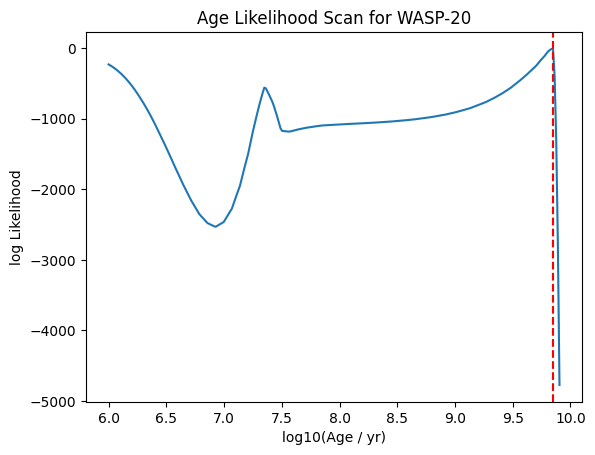

In [25]:
# WASP-20
wasp20_distance_pc = 290.0
wasp20_mags_app = {
    'J_mag': 9.701, 'K_mag': 9.39, 'G_mag': 10.83910942, 'BP_mag': 10.94779873, 'RP_mag': 10.19077778
}
wasp20_mags_abs = {band: apparent_to_absolute(m, wasp20_distance_pc) for band, m in wasp20_mags_app.items()}
y_wasp20 = np.array([wasp20_mags_abs[b] for b in compare_bands])
yerr_wasp20 = np.full_like(y_wasp20, 0.02)
scan_age_likelihood("WASP-20", y_wasp20, yerr_wasp20, mass=1.09, feh=0.0)

In [28]:
get_star_photometry('WASP-96')

(array([11.267     , 10.914     , 12.37217617, 12.73578644, 11.84923077]),
 array([0.02, 0.02, 0.02, 0.02, 0.02]))

In [29]:
get_star_age('WASP-96')

8.0

WASP-96:
Best log(age): 7.405
Best age: 0.03 Gyr


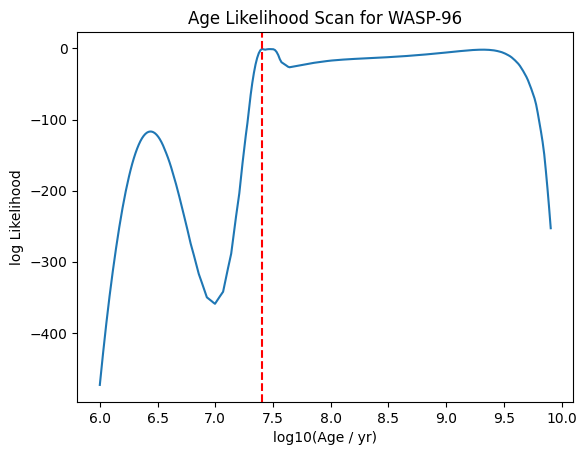

In [33]:
# WASP-96
wasp96_distance_pc = 350.0
wasp96_mags_app = {
    'J_mag': 11.267, 'K_mag': 10.914, 'G_mag': 12.37217617, 'BP_mag': 12.73578644, 'RP_mag': 11.84923077
}
wasp96_mags_abs = {band: apparent_to_absolute(m, wasp96_distance_pc) for band, m in wasp96_mags_app.items()}
y_wasp96 = np.array([wasp96_mags_abs[b] for b in compare_bands])
yerr_wasp96 = np.full_like(y_wasp96, 0.05)
scan_age_likelihood("WASP-96", y_wasp96, yerr_wasp96, mass=1.06, feh=0.14)